# Experiment results for model scaling
Here you can find plots of the experiment results on the scaling of SOTA models, as part of my thesis. Again, the 2 deep learning model architectures tested are transformer and LSTM, trained with the following parameters:
- Transformer: 35 epochs with early stopping
- LSTM: 10 epochs with early stopping

Also, the experiments were performed for:
- 100% of the dataset
- 10% of the dataset
- 1% of the dataset

The dataset was created by randomly sampling by equal amounts from all datasets, while preserving class balance (50% benign, 50% malicious samples)

## Loading the required python packages
Loading python packages and useful global functions and variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

REPORTS_PATH = "../../results/reports/statistical_significance_test"

## With network specific features
Binary metrics:


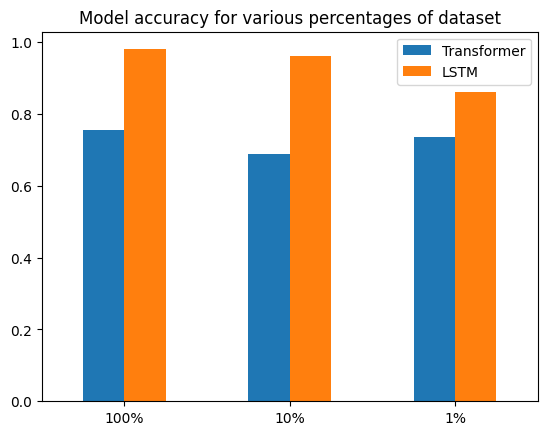

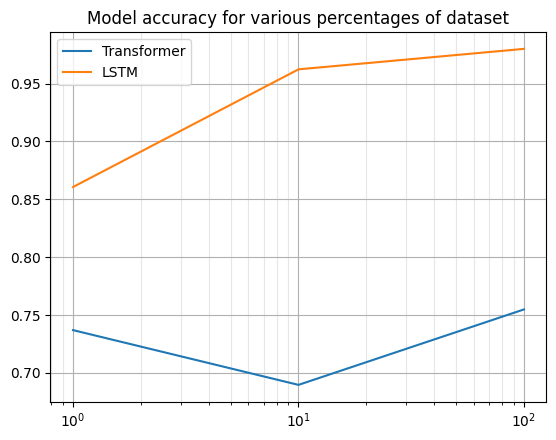

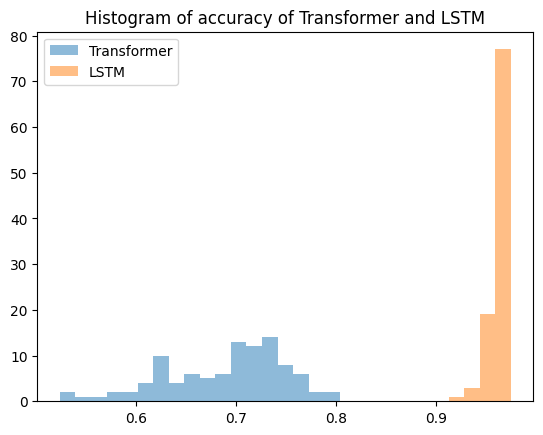

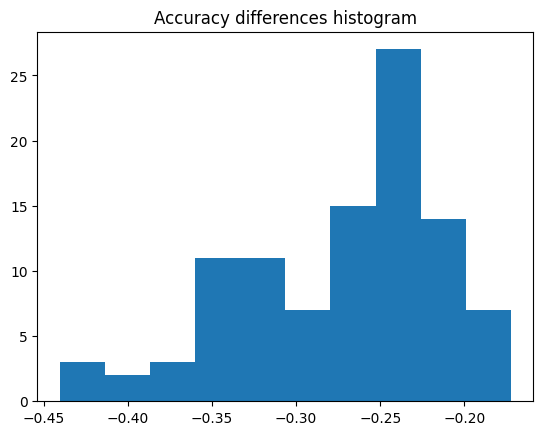

In [2]:
transformer_full_csv = os.path.join(REPORTS_PATH,"full_dataset/with_network_specific_features/transformer_35_epochs_early_stop/results_transformer_comparator.csv")
lstm_full_csv = os.path.join(REPORTS_PATH, "full_dataset/with_network_specific_features/transformer_35_epochs_early_stop/results_lstm_comparator.csv")
transformer_10_csv = os.path.join(REPORTS_PATH, "10_percent_dataset/with_network_specific_features/transformer_35_epochs_early_stop/results_transformer_comparator_10.csv")
lstm_10_csv = os.path.join(REPORTS_PATH, "10_percent_dataset/with_network_specific_features/transformer_35_epochs_early_stop/results_lstm_comparator_10.csv")
transformer_1_csv = os.path.join(REPORTS_PATH, "1_percent_dataset/with_network_specific_features/transformer_35_epochs_early_stop/results_transformer_comparator_1.csv")
lstm_1_csv = os.path.join(REPORTS_PATH, "1_percent_dataset/with_network_specific_features/transformer_35_epochs_early_stop/results_lstm_comparator_1.csv")

transformer_full_df = pd.read_csv(transformer_full_csv)
lstm_full_df = pd.read_csv(lstm_full_csv)
transformer_10_df = pd.read_csv(transformer_10_csv)
lstm_10_df = pd.read_csv(lstm_10_csv)
transformer_1_df = pd.read_csv(transformer_1_csv)
lstm_1_df = pd.read_csv(lstm_1_csv)


data = [    [transformer_full_df["Accuracy"].mean(), lstm_full_df["Accuracy"].mean(),
             (transformer_full_df["Accuracy"].mean() + lstm_full_df["Accuracy"].mean()) / 2],
            [transformer_10_df["Accuracy"].mean(), lstm_10_df["Accuracy"].mean(),
             (transformer_10_df["Accuracy"].mean() + lstm_10_df["Accuracy"].mean()) / 2],
            [transformer_1_df["Accuracy"].mean(), lstm_1_df["Accuracy"].mean(),
             (transformer_1_df["Accuracy"].mean() + lstm_1_df["Accuracy"].mean()) / 2]
        ]

data_no_mean = [    [transformer_full_df["Accuracy"].mean(), lstm_full_df["Accuracy"].mean()],
                    [transformer_10_df["Accuracy"].mean(), lstm_10_df["Accuracy"].mean()],
                    [transformer_1_df["Accuracy"].mean(), lstm_1_df["Accuracy"].mean()]
        ]

metrics_df_str = pd.DataFrame(data_no_mean, columns=["Transformer", "LSTM"], index=["100%", "10%", "1%"])
metrics_df_num = metrics_df_str.copy()
metrics_df_num.index = [100,10,1]

ax = metrics_df_str.plot(kind='bar', rot=0)
ax.set_title("Model accuracy for various percentages of dataset")
fig = ax.get_figure()
fig.savefig('model_accuracy_scaling_bar_35_nomean.pdf')

ax = metrics_df_num.plot(kind='line', rot=0)
ax.set_title("Model accuracy for various percentages of dataset")
ax.semilogx()
ax.grid()
ax.grid(which='minor', color='0.9')
fig = ax.get_figure()
fig.savefig('model_accuracy_scaling_line_35_nomean.pdf')

fig2, ax2 = plt.subplots()
bins = np.linspace(
    min(transformer_10_df["Accuracy"].min(), lstm_10_df["Accuracy"].min()),
    max(transformer_10_df["Accuracy"].max(), lstm_10_df["Accuracy"].max()),
    30  # number of bins (adjust as needed)
)
ax2.hist(transformer_10_df["Accuracy"], bins, label="Transformer", alpha=0.5)
ax2.hist(lstm_10_df["Accuracy"], bins, label="LSTM", alpha=0.5)
ax2.set_title("Histogram of accuracy of Transformer and LSTM")
ax2.legend()
fig2.savefig("model_accuracy_scaling_histogram_10.pdf")

fig2, ax2 = plt.subplots()
ax2.hist(transformer_10_df["Accuracy"] - lstm_10_df["Accuracy"])
ax2.set_title("Accuracy differences histogram")
fig2.savefig("model_accuracy_scaling_histogram_10_diff.pdf")

## Without network specific features
Binary metrics:


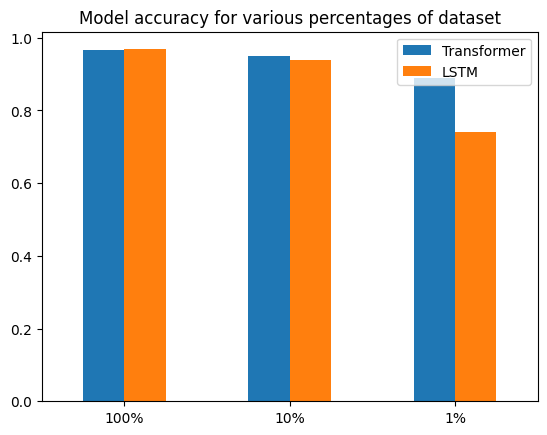

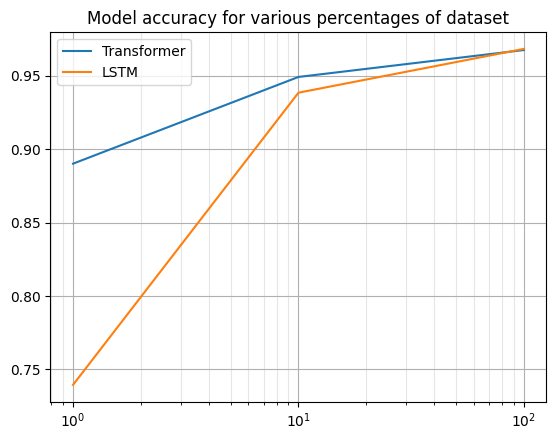

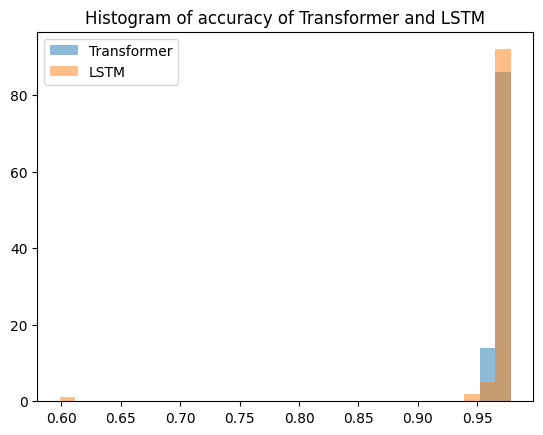

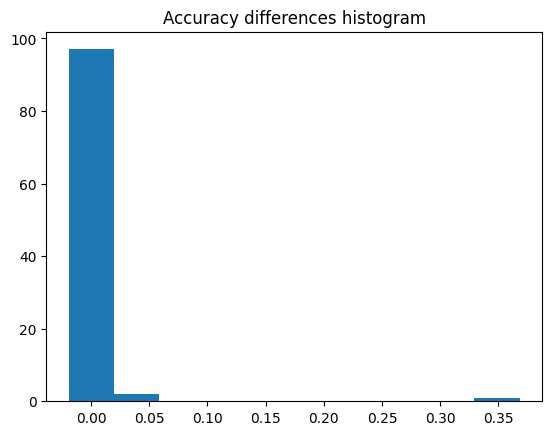

In [3]:
transformer_full_csv = os.path.join(REPORTS_PATH,"full_dataset/separate_removed_features/results_transformer_comparator_removed.csv")
lstm_full_csv = os.path.join(REPORTS_PATH, "full_dataset/separate_removed_features/results_lstm_comparator_removed.csv")
transformer_10_csv = os.path.join(REPORTS_PATH, "10_percent_dataset/separate_removed_features/results_transformer_comparator_removed_10.csv")
lstm_10_csv = os.path.join(REPORTS_PATH, "10_percent_dataset/separate_removed_features/results_lstm_comparator_removed_10.csv")
transformer_1_csv = os.path.join(REPORTS_PATH, "1_percent_dataset/separate_removed_features/results_transformer_comparator_removed_1.csv")
lstm_1_csv = os.path.join(REPORTS_PATH, "1_percent_dataset/separate_removed_features/results_lstm_comparator_removed_1.csv")

transformer_full_df = pd.read_csv(transformer_full_csv)
lstm_full_df = pd.read_csv(lstm_full_csv)
transformer_10_df = pd.read_csv(transformer_10_csv)
lstm_10_df = pd.read_csv(lstm_10_csv)
transformer_1_df = pd.read_csv(transformer_1_csv)
lstm_1_df = pd.read_csv(lstm_1_csv)


data = [    [transformer_full_df["Accuracy"].mean(), lstm_full_df["Accuracy"].mean(),
             (transformer_full_df["Accuracy"].mean() + lstm_full_df["Accuracy"].mean())/2 ],
            [transformer_10_df["Accuracy"].mean(), lstm_10_df["Accuracy"].mean(),
             (transformer_10_df["Accuracy"].mean() + lstm_10_df["Accuracy"].mean())/2],
            [transformer_1_df["Accuracy"].mean(), lstm_1_df["Accuracy"].mean(),
             (transformer_1_df["Accuracy"].mean() + lstm_1_df["Accuracy"].mean())/2]
        ]
data_no_mean = [    [transformer_full_df["Accuracy"].mean(), lstm_full_df["Accuracy"].mean() ],
                    [transformer_10_df["Accuracy"].mean(), lstm_10_df["Accuracy"].mean()],
                    [transformer_1_df["Accuracy"].mean(), lstm_1_df["Accuracy"].mean()]
        ]

metrics_df_str = pd.DataFrame(data_no_mean, columns=["Transformer", "LSTM"], index=["100%", "10%", "1%"])
metrics_df_num = metrics_df_str.copy()
metrics_df_num.index = [100,10,1]

ax = metrics_df_str.plot(kind='bar', rot=0)
ax.set_title("Model accuracy for various percentages of dataset")
fig = ax.get_figure()
fig.savefig('model_accuracy_scaling_removed_bar_35_nomean.pdf')

ax = metrics_df_num.plot(kind='line', rot=0)
ax.set_title("Model accuracy for various percentages of dataset")
ax.semilogx()
ax.grid()
ax.grid(which='minor', color='0.9')
fig = ax.get_figure()
fig.savefig('model_accuracy_scaling_removed_line_35_nomean.pdf')

fig2, ax2 = plt.subplots()
bins = np.linspace(
    min(transformer_full_df["Accuracy"].min(), lstm_full_df["Accuracy"].min()),
    max(transformer_full_df["Accuracy"].max(), lstm_full_df["Accuracy"].max()),
    30  # number of bins (adjust as needed)
)
ax2.hist(transformer_full_df["Accuracy"], bins, label="Transformer", alpha=0.5)
ax2.hist(lstm_full_df["Accuracy"], bins, label="LSTM", alpha=0.5)
ax2.set_title("Histogram of accuracy of Transformer and LSTM")
ax2.legend()
fig2.savefig("model_accuracy_scaling_histogram_full_removed.pdf")

fig2, ax2 = plt.subplots()
ax2.hist(transformer_full_df["Accuracy"] - lstm_full_df["Accuracy"])
ax2.set_title("Accuracy differences histogram")
fig2.savefig("model_accuracy_scaling_histogram_full_diff_removed.pdf")
